In [1]:
import sklearn
from sklearn.datasets import make_circles
n_samples = 1000
X, y = make_circles(n_samples, noise=0.03, random_state=42)
len(X),len(y)

(1000, 1000)

In [2]:
print(f"First 5 samples of X: {X[:5]}")
print(f"First 5 samples ofy: {y[:5]}")

First 5 samples of X: [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples ofy: [1 1 1 1 0]


In [3]:
import pandas as pd
circles = pd.DataFrame({"Feature 1": X[:, 0], "Feature 2": X[:, 1], "Target": y})
circles.head(10)


,Feature 1,Feature 2,Target
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


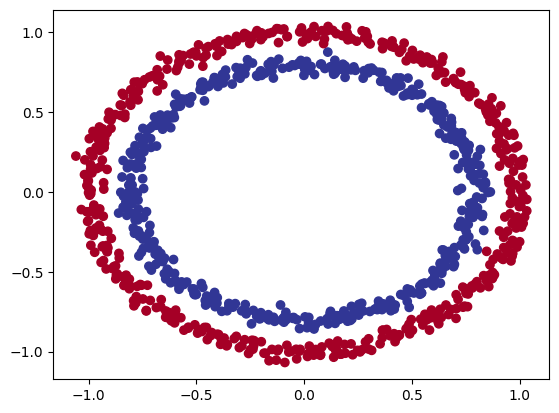

In [4]:
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0], y=X[:, 1], c=y, cmap=plt.cm.RdYlBu)
plt.show()

In [5]:
import torch
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
X[:5],y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [7]:
import torch
from torch import nn
device = cuda if torch.cuda.is_available() else "cpu"
device

'cpu'

In [8]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=5)
    self.layer_2 = nn.Linear(in_features=5, out_features=1)

  def forward(self, x):
    return self.layer_2(self.layer_1(x))

model_0 = CircleModelV1().to(device)
model_0

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [9]:
next(model_0.parameters()).device

device(type='cpu')

The below code and
class CircleModelV1(nn.Module): code do have the same functionality


In [10]:
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
    ).to(device)
model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [11]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.4841,  0.0817],
                      [ 0.3453,  0.2675],
                      [-0.4428, -0.6470],
                      [-0.7038,  0.0077],
                      [ 0.4029,  0.2951]])),
             ('0.bias', tensor([-0.3048, -0.3124, -0.6733, -0.1031,  0.3849])),
             ('1.weight',
              tensor([[ 0.0282, -0.3553,  0.3405,  0.0240,  0.1864]])),
             ('1.bias', tensor([-0.1244]))])

In [12]:
with torch.inference_mode():
  untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}")
print(f"Shape of predictions: {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}, Shape of test samples: {X_test.shape}")
print(f"First 10 predictions: {untrained_preds[:10]}")
print(f"First 10 labels: {y_test[:10]}")

Length of predictions: 200
Shape of predictions: torch.Size([200, 1])
Length of test samples: 200, Shape of test samples: torch.Size([200, 2])
First 10 predictions: tensor([[-0.2823],
        [-0.4326],
        [ 0.0409],
        [-0.3736],
        [-0.0713],
        [-0.1621],
        [-0.4963],
        [-0.4332],
        [ 0.0451],
        [-0.4439]])
First 10 labels: tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [13]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

In [14]:
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct / len(y_pred)) * 100
  return acc

In [15]:
y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.2823],
        [-0.4326],
        [ 0.0409],
        [-0.3736],
        [-0.0713]], grad_fn=<SliceBackward0>)

In [16]:
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4299],
        [0.3935],
        [0.5102],
        [0.4077],
        [0.4822]], grad_fn=<SigmoidBackward0>)

In [17]:
y_preds = torch.round(y_pred_probs)
y_preds_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

print(torch.eq(y_preds.squeeze(), y_preds_labels.squeeze()))

tensor([True, True, True, True, True])


In [18]:
torch.manual_seed(42)
epochs = 1000


for epoch in range(epochs):
  model_0.train()

  #forward pass
  y_logits = model_0(X_train.to(device)).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  #loss and optimizer
  loss = loss_fn(y_logits, y_train.to(device))
  acc = accuracy_fn(y_true=y_train, y_pred=y_pred)
  optimizer.zero_grad()

  #backpropagation (loss backward)
  loss.backward()

  #optimizer step
  optimizer.step()

  model_0.eval()
  with torch.inference_mode():
    test_logits = model_0(X_test.to(device)).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test.to(device))
    test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")


Epoch: 0 | Loss: 0.70424, Acc: 46.00% | Test Loss: 0.69567, Test Acc: 51.50%
Epoch: 10 | Loss: 0.69896, Acc: 47.62% | Test Loss: 0.69204, Test Acc: 52.00%
Epoch: 20 | Loss: 0.69669, Acc: 48.00% | Test Loss: 0.69100, Test Acc: 53.00%
Epoch: 30 | Loss: 0.69557, Acc: 48.00% | Test Loss: 0.69083, Test Acc: 54.00%
Epoch: 40 | Loss: 0.69493, Acc: 48.62% | Test Loss: 0.69096, Test Acc: 55.00%
Epoch: 50 | Loss: 0.69451, Acc: 48.50% | Test Loss: 0.69118, Test Acc: 54.00%
Epoch: 60 | Loss: 0.69422, Acc: 49.38% | Test Loss: 0.69142, Test Acc: 55.00%
Epoch: 70 | Loss: 0.69401, Acc: 49.62% | Test Loss: 0.69166, Test Acc: 54.00%
Epoch: 80 | Loss: 0.69384, Acc: 49.75% | Test Loss: 0.69189, Test Acc: 53.00%
Epoch: 90 | Loss: 0.69371, Acc: 49.75% | Test Loss: 0.69210, Test Acc: 53.50%
Epoch: 100 | Loss: 0.69361, Acc: 50.00% | Test Loss: 0.69229, Test Acc: 52.50%
Epoch: 110 | Loss: 0.69353, Acc: 50.38% | Test Loss: 0.69246, Test Acc: 50.50%
Epoch: 120 | Loss: 0.69346, Acc: 50.75% | Test Loss: 0.69262, T

In [19]:
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print("File already exists")
else:
  print("Download helper_function.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions , plot_decision_boundary


Download helper_function.py


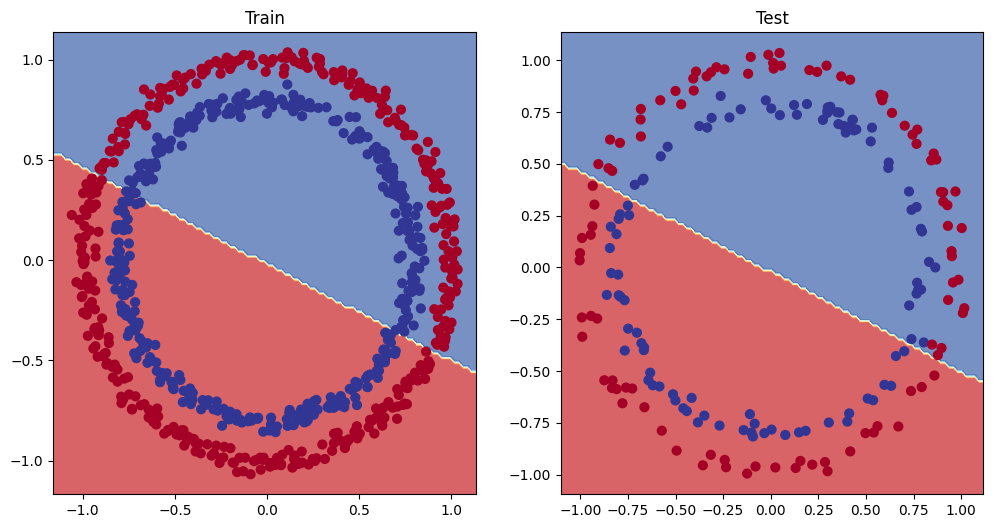

In [20]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

In [26]:
class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)

  def forward(self, x):
    return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = CircleModelV2().to(device)
model_1

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [27]:
model_1.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[-0.2435, -0.3386],
                      [-0.5755,  0.5929],
                      [-0.2830,  0.1874],
                      [-0.2453,  0.0575],
                      [ 0.6592,  0.3258],
                      [-0.6128,  0.2807],
                      [ 0.6712,  0.1860],
                      [ 0.4741,  0.6971],
                      [-0.1083,  0.1468],
                      [-0.4915, -0.1457]])),
             ('layer_1.bias',
              tensor([ 0.5237,  0.3625, -0.4474, -0.5670, -0.4832, -0.6978, -0.5456, -0.1749,
                       0.4772,  0.1184])),
             ('layer_2.weight',
              tensor([[-0.2405, -0.2537,  0.1573, -0.2352, -0.0389,  0.1517, -0.1464, -0.0345,
                       -0.0275, -0.0748],
                      [-0.1603, -0.2819, -0.2556, -0.1693,  0.3054, -0.1527, -0.2124,  0.0767,
                        0.0872,  0.1733],
                      [ 0.2404,  0.1761, -0.3135,  0.0280,  0.1916, -0.0

In [28]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

In [29]:
torch.manual_seed(42)
epochs = 1000


for epoch in range(epochs):
  model_1.train()

  #forward pass
  y_logits = model_1(X_train.to(device)).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  #loss and optimizer
  loss = loss_fn(y_logits, y_train.to(device))
  acc = accuracy_fn(y_true=y_train, y_pred=y_pred)
  optimizer.zero_grad()

  #backpropagation (loss backward)
  loss.backward()

  #optimizer step
  optimizer.step()

  model_1.eval()
  with torch.inference_mode():
    test_logits = model_1(X_test.to(device)).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test.to(device))
    test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")


Epoch: 0 | Loss: 0.71086, Acc: 50.00% | Test Loss: 0.70706, Test Acc: 50.00%
Epoch: 100 | Loss: 0.69309, Acc: 49.00% | Test Loss: 0.69348, Test Acc: 49.00%
Epoch: 200 | Loss: 0.69300, Acc: 50.88% | Test Loss: 0.69425, Test Acc: 46.00%
Epoch: 300 | Loss: 0.69298, Acc: 51.12% | Test Loss: 0.69452, Test Acc: 45.50%
Epoch: 400 | Loss: 0.69298, Acc: 51.25% | Test Loss: 0.69462, Test Acc: 45.50%
Epoch: 500 | Loss: 0.69298, Acc: 51.25% | Test Loss: 0.69466, Test Acc: 46.00%
Epoch: 600 | Loss: 0.69298, Acc: 51.12% | Test Loss: 0.69467, Test Acc: 46.00%
Epoch: 700 | Loss: 0.69298, Acc: 51.12% | Test Loss: 0.69468, Test Acc: 46.00%
Epoch: 800 | Loss: 0.69298, Acc: 51.12% | Test Loss: 0.69468, Test Acc: 46.00%
Epoch: 900 | Loss: 0.69298, Acc: 51.00% | Test Loss: 0.69468, Test Acc: 46.00%


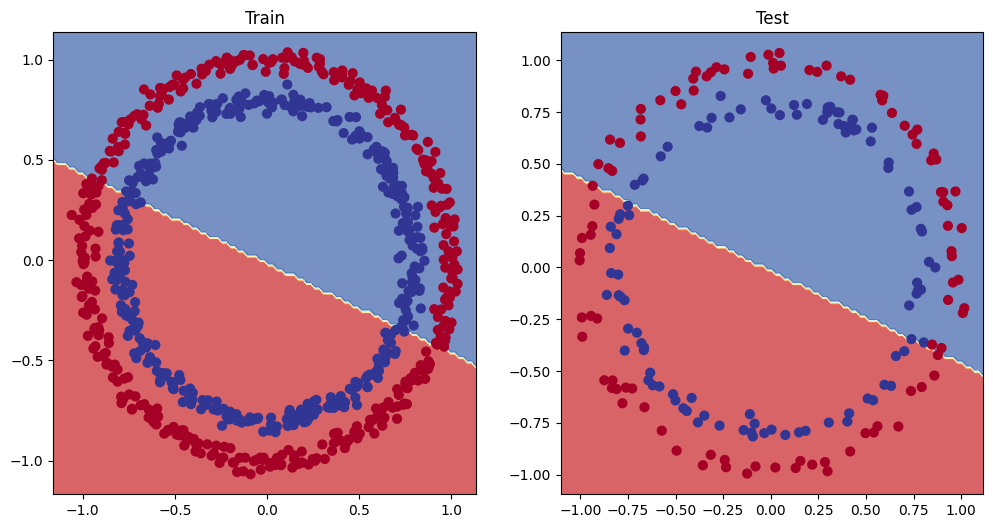

In [30]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

Troubleshooting (see if it works in a smaller problem)

In [31]:
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01
X_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias
X[:10], y[:10]

print(len(X_regression), len(y_regression))
X_regression[:10], y_regression[:10]

100 100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400],
         [0.0500],
         [0.0600],
         [0.0700],
         [0.0800],
         [0.0900]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280],
         [0.3350],
         [0.3420],
         [0.3490],
         [0.3560],
         [0.3630]]))

In [32]:
train_split = int(0.8 * len(X_regression))
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]

len(X_train_regression), len(y_train_regression), len(X_test_regression), len(y_test_regression)

(80, 80, 20, 20)

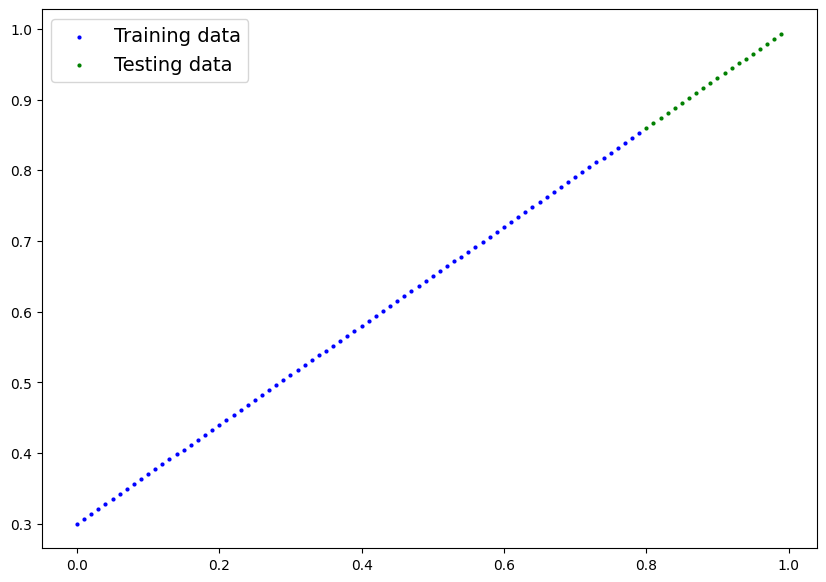

In [33]:
plot_predictions(train_data=X_train_regression,
                 train_labels=y_train_regression,
                 test_data=X_test_regression,
                 test_labels=y_test_regression,
                 predictions=None)